In [94]:
#импортируем нужные либы
import pandahouse as ph
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline 

In [6]:
#объявляем параметры подключения
connection = dict(database='test',
                  host='https://clickhouse.lab.karpov.courses',
                  user='student',
                  password='dpo_python_2020')

In [7]:
#пишем запрос, и получаем данные из clickhouse в pandas dataframe
query = """
SELECT count() rows
FROM ldn_listings
LIMIT 1000
"""
df = ph.read_clickhouse(query, connection=connection)
df

,rows
0,85207


In [15]:
#пишем запрос, и получаем данные из clickhouse в pandas dataframe
query = """
SELECT
    room_type,
    toFloat32OrNull(replaceRegexpAll(price,'[$,]', '')) as price
FROM ldn_listings
ORDER BY id    
LIMIT 1000
"""
df = ph.read_clickhouse(query, connection=connection)
df

,room_type,price
0,Private room,65.0
1,Entire home/apt,100.0
2,Entire home/apt,300.0
3,Private room,150.0
4,Entire home/apt,65.0
...,...,...
995,Entire home/apt,110.0
996,Entire home/apt,110.0
997,Private room,65.0
998,Entire home/apt,100.0


In [17]:
df.groupby('room_type', as_index = False).quantile(q=0.75)

,room_type,price
0,Entire home/apt,160.00
1,Hotel room,157.00
2,Private room,70.00
3,Shared room,69.25


In [22]:
#пишем запрос, и получаем данные из clickhouse в pandas dataframe
query = """
SELECT
    room_type,
    toFloat32OrNull(replaceRegexpAll(price,'[$,]', '')) as price,
    toFloat32OrNull(review_scores_rating) as review_scores_rating
FROM ldn_listings
WHERE review_scores_rating is not null
ORDER BY id    
LIMIT 1000
"""
df = ph.read_clickhouse(query, connection=connection)
df

,room_type,price,review_scores_rating
0,Private room,65.0,97.0
1,Entire home/apt,100.0,96.0
2,Entire home/apt,300.0,94.0
3,Entire home/apt,65.0,93.0
4,Private room,29.0,96.0
...,...,...,...
995,Entire home/apt,165.0,100.0
996,Private room,99.0,93.0
997,Private room,45.0,100.0
998,Private room,20.0,88.0


In [27]:
df2 = df.groupby('room_type', as_index = False)\
    .agg({'price': 'mean', 'review_scores_rating': 'mean'})
df2

,room_type,price,review_scores_rating
0,Entire home/apt,135.882950,93.568787
1,Hotel room,134.000000,92.500000
2,Private room,54.642437,94.766205
3,Shared room,21.000000,90.000000


<Axes: xlabel='price', ylabel='review_scores_rating'>

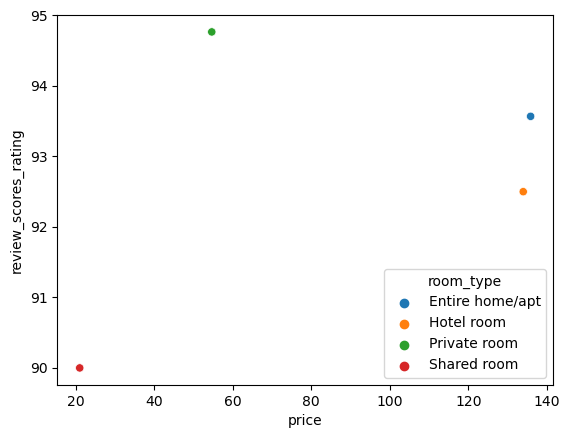

In [29]:
sns.scatterplot(data=df2, x='price', y='review_scores_rating', hue='room_type')

In [61]:
#пишем запрос, и получаем данные из clickhouse в pandas dataframe
query = """
SELECT
    DISTINCT host_id,
    host_verifications
FROM ldn_listings
WHERE experiences_offered != 'none'
ORDER BY id    
"""
df3 = ph.read_clickhouse(query, connection=connection)
df3

,host_id,host_verifications
0,54730,"['email', 'phone', 'facebook', 'reviews', 'off..."
1,60302,"['email', 'phone', 'reviews', 'jumio', 'govern..."
2,67915,"['email', 'phone', 'jumio', 'selfie', 'governm..."
3,167107,"['email', 'phone', 'manual_offline', 'jumio', ..."
4,103583,"['email', 'phone', 'reviews', 'offline_governm..."
...,...,...
1356,21558962,"['email', 'phone', 'reviews', 'jumio', 'govern..."
1357,21257846,"['email', 'phone', 'reviews', 'jumio', 'offlin..."
1358,34219613,"['email', 'phone', 'reviews', 'jumio', 'govern..."
1359,34299581,"['email', 'phone', 'google', 'reviews', 'jumio..."


In [47]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   host_id             1548 non-null   uint32
 1   host_verifications  1548 non-null   object
dtypes: object(1), uint32(1)
memory usage: 18.3+ KB


In [63]:
df3.host_verifications =  df3.host_verifications.str.strip('][').str.split(', ')

In [62]:
#df3.host_verifications =  df3.host_verifications.apply(lambda x: str.strip('][').str.split(', '))

In [64]:
df3

,host_id,host_verifications
0,54730,"['email', 'phone', 'facebook', 'reviews', 'off..."
1,60302,"['email', 'phone', 'reviews', 'jumio', 'govern..."
2,67915,"['email', 'phone', 'jumio', 'selfie', 'governm..."
3,167107,"['email', 'phone', 'manual_offline', 'jumio', ..."
4,103583,"['email', 'phone', 'reviews', 'offline_governm..."
...,...,...
1356,21558962,"['email', 'phone', 'reviews', 'jumio', 'govern..."
1357,21257846,"['email', 'phone', 'reviews', 'jumio', 'offlin..."
1358,34219613,"['email', 'phone', 'reviews', 'jumio', 'govern..."
1359,34299581,"['email', 'phone', 'google', 'reviews', 'jumio..."


In [65]:
df3.host_verifications.explode().value_counts()

'phone'                    1361
'email'                    1345
'reviews'                  1309
'government_id'            1196
'jumio'                    1115
'offline_government_id'     469
'work_email'                279
'facebook'                  270
'selfie'                    252
'identity_manual'           227
'manual_offline'             70
'google'                     34
'kba'                        27
'manual_online'              16
'sent_id'                     6
Name: host_verifications, dtype: int64

In [78]:
#пишем запрос, и получаем данные из clickhouse в pandas dataframe
query = """
SELECT
    neighbourhood_cleansed,
    experiences_offered,
    count(*) as experiences_count 
FROM ldn_listings
WHERE experiences_offered != 'none'
Group by neighbourhood_cleansed, experiences_offered 
ORDER BY experiences_count     
"""
df4 = ph.read_clickhouse(query, connection=connection)
df4

ClickhouseException: b"Code: 62. DB::Exception: Syntax error: failed at position 107 ('ldn_listings') (line 4, col 6): ldn_listings\nWHERE experiences_offered != 'none'\nORDER BY experiences_count desc\nLimit 100 FORMAT TSVWithNamesAndTypes\n. Expected one of: token, Comma, Arrow, Dot, UUID, DoubleColon, MOD, DIV, NOT, BETWEEN, LIKE, ILIKE, NOT LIKE, NOT ILIKE, IN, NOT IN, GLOBAL IN, GLOBAL NOT IN, IS, AND, OR, QuestionMark, alias, AS, FROM, PREWHERE, WHERE, GROUP BY, WITH, HAVING, WINDOW, ORDER BY, LIMIT, OFFSET, SETTINGS, UNION, EXCEPT, INTERSECT, INTO OUTFILE, FORMAT, end of query. (SYNTAX_ERROR) (version 21.12.2.17 (official build))\n"

In [76]:
dg4_pivot = df4.pivot(columns='experiences_offered', index='neighbourhood_cleansed', values='experiences_count')
dg4_pivot

experiences_offered,business,family,romantic,social
neighbourhood_cleansed,,,,
Barking and Dagenham,NaN,NaN,NaN,2.0
Barnet,7.0,7.0,3.0,5.0
Bexley,1.0,NaN,NaN,NaN
Brent,9.0,21.0,5.0,6.0
Bromley,3.0,2.0,NaN,4.0
Camden,36.0,30.0,19.0,25.0
City of London,7.0,1.0,NaN,NaN
Croydon,2.0,3.0,NaN,4.0
Ealing,6.0,13.0,NaN,5.0


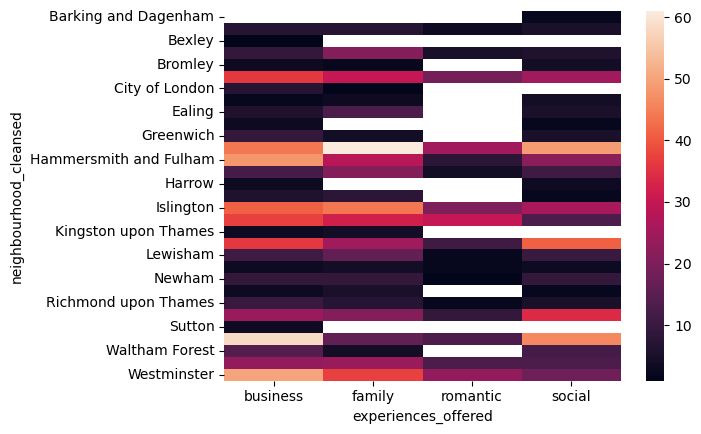

In [77]:
sns.heatmap(dg4_pivot)
cmap=sns.cubehelix_palette(as_cmap=True)

In [97]:
#пишем запрос, и получаем данные из clickhouse в pandas dataframe
query = """
SELECT
    room_type,
    toFloat32OrNull(replaceRegexpAll(price,'[$,]', '')) as price
FROM ldn_listings
WHERE experiences_offered != 'none'
"""
df5 = ph.read_clickhouse(query, connection=connection)
df5

,room_type,price
0,Private room,65.0
1,Entire home/apt,100.0
2,Private room,150.0
3,Private room,45.0
4,Private room,25.0
...,...,...
1543,Entire home/apt,100.0
1544,Entire home/apt,125.0
1545,Entire home/apt,185.0
1546,Entire home/apt,110.0


In [98]:
df5.room_type.unique()

array(['Private room', 'Entire home/apt', 'Hotel room', 'Shared room'],
      dtype=object)

C:\Users\Admin\AppData\Local\Temp\ipykernel_15808\2057485235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df5.query("room_type=='Private room'").price, kde=False, label='Private room')
C:\Users\Admin\AppData\Local\Temp\ipykernel_15808\2057485235.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.

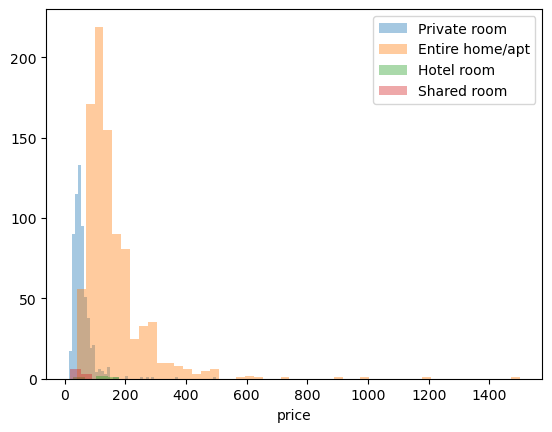

In [99]:
sns.distplot(df5.query("room_type=='Private room'").price, kde=False, label='Private room')
sns.distplot(df5.query("room_type=='Entire home/apt'").price, kde=False, label='Entire home/apt')
sns.distplot(df5.query("room_type=='Hotel room'").price, kde=False, label='Hotel room')
sns.distplot(df5.query("room_type=='Shared room'").price, kde=False, label='Shared room')

plt.legend()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_15808\179219465.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(df5.query("room_type=='Private room'").price), kde=False, label='Private room')
C:\Users\Admin\AppData\Local\Temp\ipykernel_15808\179219465.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751



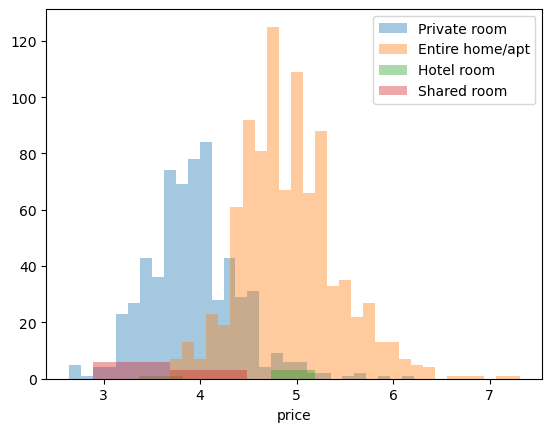

In [100]:
sns.distplot(np.log(df5.query("room_type=='Private room'").price), kde=False, label='Private room')
sns.distplot(np.log(df5.query("room_type=='Entire home/apt'").price), kde=False, label='Entire home/apt')
sns.distplot(np.log(df5.query("room_type=='Hotel room'").price), kde=False, label='Hotel room')
sns.distplot(np.log(df5.query("room_type=='Shared room'").price), kde=False, label='Shared room')

plt.legend()
plt.show()

In [108]:
#пишем запрос, и получаем данные из clickhouse в pandas dataframe
query = """
SELECT
    room_type,
    toFloat32OrNull(replaceRegexpAll(price,'[$,]', '')) as price,
    first_review
FROM ldn_listings
WHERE first_review > '2010-01-01'
Limit 1000
"""
df6 = ph.read_clickhouse(query, connection=connection)
df6

,room_type,price,first_review
0,Private room,65.0,2010-08-18
1,Entire home/apt,300.0,2011-03-21
2,Entire home/apt,65.0,2016-03-05
3,Private room,29.0,2010-04-14
4,Private room,100.0,2010-10-16
...,...,...,...
995,Private room,45.0,2012-11-07
996,Private room,51.0,2013-03-18
997,Entire home/apt,79.0,2012-09-17
998,Entire home/apt,110.0,2012-09-24


In [109]:
df6.first_review = df6.first_review.apply(lambda x: x[:-6])
df6 = df6.rename(columns = {'first_review': 'year'})
df6

,room_type,price,year
0,Private room,65.0,2010
1,Entire home/apt,300.0,2011
2,Entire home/apt,65.0,2016
3,Private room,29.0,2010
4,Private room,100.0,2010
...,...,...,...
995,Private room,45.0,2012
996,Private room,51.0,2013
997,Entire home/apt,79.0,2012
998,Entire home/apt,110.0,2012


In [112]:
df6_agg = df6\
    .groupby(['room_type', 'year'], as_index=False)\
    .agg({'price': 'mean'})\
    .sort_values('year')
df6_agg

,room_type,year,price
0,Entire home/apt,2010,103.500000
13,Private room,2010,56.428570
11,Hotel room,2010,88.000000
1,Entire home/apt,2011,128.792450
14,Private room,2011,52.607143
2,Entire home/apt,2012,135.467255
15,Private room,2012,53.269840
24,Shared room,2012,22.000000
3,Entire home/apt,2013,137.887634
16,Private room,2013,57.036587


<Axes: xlabel='year', ylabel='price'>

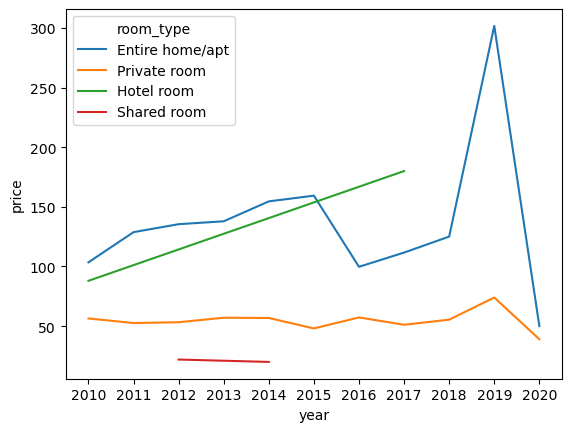

In [113]:
sns.lineplot(df6_agg, x='year', y='price', hue='room_type')